In [ ]:
!wget -q "https://drive.google.com/uc?export=download&id=1p0Y-jY1zc9F4VNProJWed5RMtNY1vRYu" -O female-births-CA.csv

# Performance Evaluation and Residual Diagnostics


## Prerequisites:

To learn performance evaluation and residual diagnostics, you need to have a proper understanding of a few basic concepts like:

- Time Series data
- Time Series Terminologies
- Residuals
- Desired Properties for Residuals


## Learning Objective:

- Understand the concept of a train-validation split in the case of time series.

- Understand the concepts of commonly used evaluation metrics: AIC and BIC.

- Understand residual diagnostics techniques for time series. 



## Train-Validation Split 

We have been randomly partitioning a given dataset into a training set and a validation set to assess the fitted models' generalization. However, in time series, such random partition is not suitable. The random partition creates holes in the data, and we cannot fit many standard models in such data. Also, the time ordering, which is a crucial dimension for the time series, gets lost with random partitioning. The sense of the past and the present, which is essential for forecasts, get lost.  Hence, we need to partition time series differently than in the conventional ML approaches. 

The first $n$ observations are designated into the training set and the later observations into the validation set to maintain the time-ordering. The length of the validation set is chosen based on the forecast horizon. For example, if the forecasting model will be used to forecast for the next year, then the validation period should include at least a year. A shorter validation period will not allow the evaluation of the predictive performance of more extended forecasts. Then, models are trained on the earlier training set and evaluated on the later validation set. We can get a sense of the performance issues and see possible improvement paths by observing the time plots of actual and predicted values for both training and validation sets.  The best model is picked by evaluating the trained models in the validation set. The general practice in time series is then to train the best model on the combined training and validation sets before making future forecasts.

The train-validation-test split is not usually done for time series. For such a split, the most recent observations would be designated in the test set. So, the performance of the fitted models would not be evaluated on the most recent observations. Also, the omission of even more recent observations is more likely to cause harm than benefit for the forecasts.




## Evaluation Metrics




### Akaike Information Criterion (AIC)

Hirotugo Akaike proposed the AIC score in 1974 in his paper "A New Look at the Statistical Model Identification".  This paper has been cited over 50 thousand times and is one of the seminal works in model selection. AIC uses log-likelihood and includes a penalty for the order of the model. It's defined as follows:
$$
\text{AIC} = - 2 \log \big[ \mathcal{L(\hat{\boldsymbol{\mu}}|\mathbb{x})}\big] + 2 K
$$
where $K$ is the number of model parameters, also called the order of the model, and $\mathcal{L(\hat{\boldsymbol{\mu}}|\mathbb{x})}$ denotes the maximum likelihood obtained by MLE. We want the goodness-of-fit (log-likelihood) to be as high as possible, ensuring the model has fitted the data properly. And to counterbalance the model's overfitting, we don't want the model to have a very high order. It's because the higher-order models can overfit on the training data. Thus, we want higher likelihood but lower order for the model inferring the lower the value of AIC, the better. 


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

from scipy import optimize
from statsmodels.tsa import stattools
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.statespace import tools 

/usr/local/lib/python3.6/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:
def plot_series(X, X_=None, title='Time Series Plot', y_label='Value of X', 
                figsize=(16, 5), forecast=False, season=12):
    
    """ Plots the time series data X.

    Args:
        X (np.array): Time-series data
        X_ (np.array): Forecasted time-series data
        title (str) - Title for the figure
        y_label (str) - y-label for the figure
        figsize (tuple): Size of figure
        forecast (bool): if true appends predictions after observed data
        season (int): season

    """

    fig = plt.figure(figsize=figsize)
    
    plt.plot(X, linewidth=3)

    if X_ is not None:
        if not forecast:
            plt.plot(X_, linewidth=3)
        else:
            plt.plot(range(len(X), len(X_) + len(X)), X_)

    plt.title(title, fontsize=16)
    plt.xlabel('Time', fontsize=14)
    plt.ylabel(y_label, fontsize=14)
    
    plt.xticks(
        range(0, len(X) + 1 if not forecast else len(X) + len(X_) + 1, season), 
        fontsize=14
    ) 
    
    if X_ is not None:
        plt.legend(['True Values', 'Forecasted Values'], fontsize=14)
    plt.grid()
    plt.show()


def plot_graphs(X=None, lags=121, season=12, figsize=(10, 5)):
    """ Plots ACF and PACF graphs
        
    Args:
        X (np.array): Time-series data
        lags (int): number of lags up to which ACF and PACF plots will be shown
        season (int): season  
        figsize (tuple): size for the figure
    
    """
    
    fig = plt.figure(figsize=figsize)
    fig.subplots_adjust(hspace=0.5)

    title = 'Autocorrelation Plot'
    ax1 = fig.add_subplot(211)
    sm.graphics.tsa.plot_acf(X, title=title, ax=ax1, lags=lags)
    plt.title(title, fontsize=14)
    plt.xticks(range(0, lags, season), fontsize=14)
    plt.grid()

    title = 'Partial Autocorrelation Plot'  
    ax2 = fig.add_subplot(212)
    sm.graphics.tsa.plot_pacf(X, title=title,  ax=ax2, lags=lags, method='ywmle',)
    plt.title(title, fontsize=14)
    plt.xticks(range(0, lags + 1, season), fontsize=14)
    plt.grid()
    plt.show()

In [ ]:
ar_params = np.array([0.3, -0.15, 0.15, -0.1, 0.1, 0.1]) # phi_1 
ma_params = np.array([0.4, 0.13, 0.25, 0.14, 0.14, 0.12, 0.01]) # theta_1

ar = np.r_[1, -ar_params] # stacking 1 allows to include lag 0 in AR parameters
ma = np.r_[1, ma_params] # stacking 1 allows to include lag 0 in MA parameters  

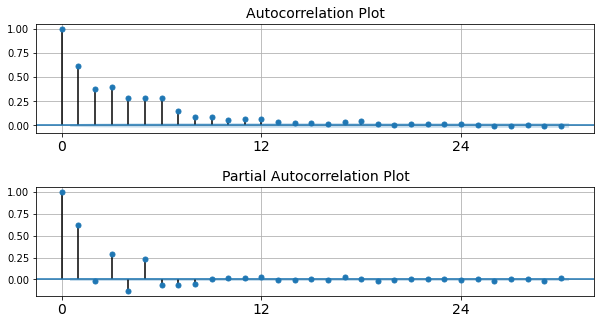

In [ ]:
# build an AR process
ma_process = ArmaProcess(ar, ma) 

np.random.seed(9999)
# generates 2500 samples of time series data using the ARMA model 
X = ma_process.generate_sample(nsample=20000) 
plot_graphs(X, lags=30)

In [ ]:
model1 = sm.tsa.ARIMA(
    X, 
    order=(5, 0, 5), 
).fit(trend='nc')

model2 = sm.tsa.ARIMA(
    X, 
    order=(1, 0, 2), 
).fit(trend='nc')

In [ ]:
print('AIC for model1 =', model1.aic)
print('AIC for model1 =', model2.aic)

AIC for model1 = 56691.52824728064
AIC for model1 = 58106.61524032235


### Bayesian Information Criterion (BIC)

There've been serveral modifications to AIC score. BIC is one of them. Gideon Schwarz proposed BIC in 1978 in his paper "The annals of Statistics". BIC is defined as:

$$
\text{BIC} = - 2 \log \big[\mathcal{L(\hat{\boldsymbol{\mu}}|\mathbb{x})} \big] + \log(n) K
$$

where $n$ is the number of data points. BIC's identical to AIC aside from penalization by the number of data points. 


In [ ]:
print('BIC for model1 =', model1.bic)
print('BIC for model1 =', model2.bic)

BIC for model1 = 56778.46661035854
BIC for model1 = 58138.2291905325


## Residual Diagnostics

After the model has been fitted, another way to evaluate the performance is to analyze the residuals. We can check if the fitted model has adequately captured the information in the data or not by residual diagnostics. Residual for timestamp $t$ $e_t$ is equal to the difference between the observation $x_t$ and the fitted value $\hat{x}_t$ i.e.

$$e_t = x_t - \hat{x}_t.$$

We expect that you've studied about residuals in the prior units. We won't go into the details of the desired properties of residuals. Let's recap some desired properties here.

1. The residuals are uncorrelated. 

2. The residuals have constant variance.

3. The residuals have zero mean and are normally distributed.

Let's look at some of the ways we can validate the above properties.


### ACF Plot of Residuals

We can plot the ACF for the residuals to check if any autocorrelations are present in the residuals. We expect that the autocorrelations for lags 1, 2, ... are significantly low for a properly fitted model. 


/usr/local/lib/python3.6/dist-packages/statsmodels/tsa/stattools.py:541: FutureWarning: fft=True will become the default in a future version of statsmodels. To suppress this warning, explicitly set fft=False.
  warnings.warn(msg, FutureWarning)


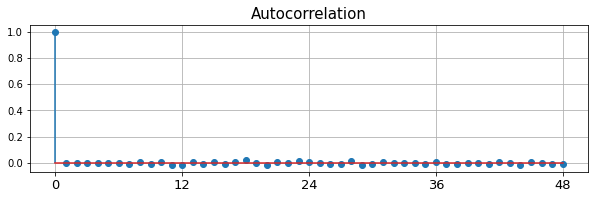

In [ ]:
autocorrelations = stattools.acf(model1.resid[:], nlags=48)

fig = plt.figure(figsize=(10, 2.7))
plt.stem(autocorrelations,  use_line_collection=True)
plt.title('Autocorrelation', fontsize=15)
plt.xticks(range(0, 49, 12), fontsize=13)
plt.grid()
plt.show()

### Time Series Plot for Residuals

We can plot the residuals to check whether the variance is constant or not. The check is tentative and based solely on observation.


In [ ]:
# plt.figure(figsize=(10, 6))
plt.plot(model1.resid[:])
plt.plot()

### Histogram Plot of Residuals

We can observe the histogram for the residuals and check if the residuals have zero mean and are normally distributed or not. The non-zero mean condition for residuals infers the presence of bias in the model.


[]

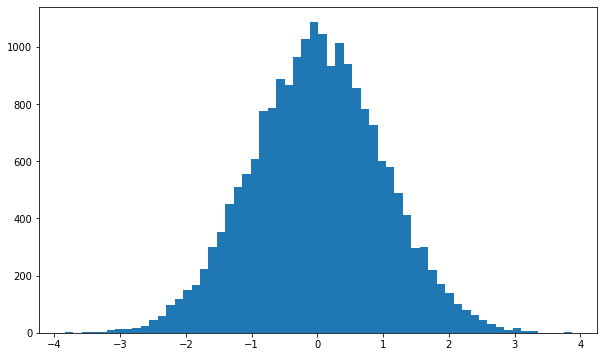

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(model1.resid[:], bins=60)
plt.plot()

## Key Takeaways

1.

2.

3.
